In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

from tqdm.notebook import tqdm
# !pip install ipywidgets

In [3]:
import acsmuthi.utility.mathematics as mths
from acsmuthi.linear_system.coupling.substrate_coupling_matrix import substrate_coupling_block_integrate, substrate_coupling_element, substrate_coupling_block
from acsmuthi.linear_system.coupling.coupling_basics import k_contour
from acsmuthi.medium import FluidMedium, ElasticMedium, RigidBoundary, MediumSystem

### spectrum

In [4]:
from acsmuthi.initial_field import PlaneWave
from acsmuthi.particles import SphericalParticle
from acsmuthi.simulation import Simulation
from acsmuthi.postprocessing.forces import all_forces

In [5]:

def two_water_spheres_above_hard_substrate(distance):
    NMAX = 3
    
    # Water
    RHO_MED = 997
    C_MED = 1480

    # Particle
    C_PAR = 1020
    RHO_PAR = 1045
    R_PAR = 100e-6

    DZ = 3.2 * R_PAR

    # Field
    KA = 1
    K = KA / R_PAR
    FREQ = K * C_MED / 2 / np.pi
    P0 = 50e3
    DIR = np.array([0., 0., -1])
    
    pos1 = np.array([-distance/2, 0, DZ])  # [m]
    pos2 = np.array([distance/2, 0., DZ])  # [m]

    incident_field = PlaneWave(k=K, amplitude=P0, direction=DIR)

    fluid = MediumSystem([
            FluidMedium(density=RHO_MED, sound_speed_longitudinal=C_MED), 
            RigidBoundary()
        ])

    particles = tuple(
        SphericalParticle(
            position=pos, 
            radius=R_PAR, 
            density=RHO_PAR, 
            sound_speed_longitudinal=C_PAR,
            multipole_order=NMAX
        ) for pos in (pos1, pos2)
    )

    sim = Simulation(
        particles=np.array(particles), 
        medium=fluid, 
        initial_field=incident_field, 
        frequency=FREQ, 
        order=NMAX
    )
    sim.run()

    frcs = all_forces(sim)
    return frcs[1][0]

In [6]:
R_PAR = 100e-6
K = 1 / R_PAR

kdistances = np.linspace(2.5, 17, 50)
forces = np.zeros_like(kdistances)
for i, kd in enumerate(tqdm(kdistances)):
    f = two_water_spheres_above_hard_substrate(kd / K)
    forces[i] = f

  0%|          | 0/50 [00:00<?, ?it/s]

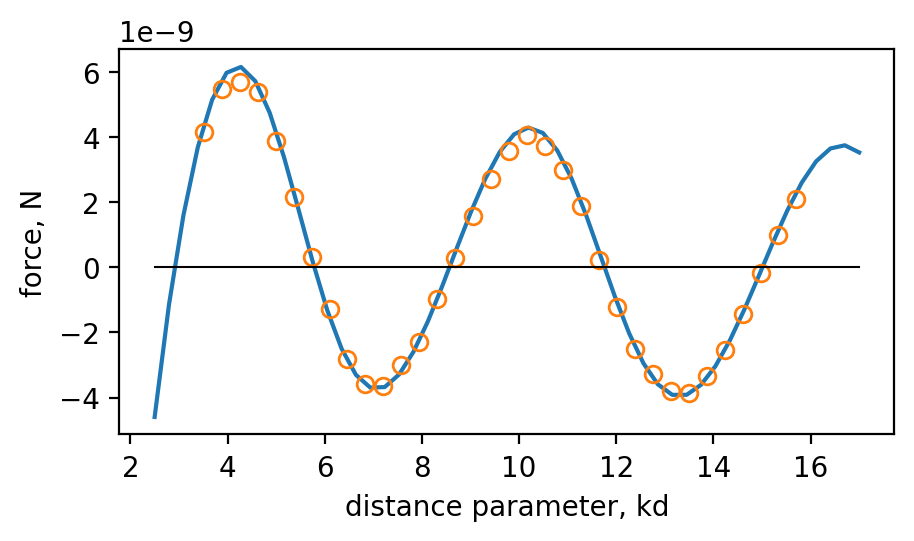

In [7]:
comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwh_dx_32_comsol.csv", delimiter=",", skiprows=5, dtype=float)

fx_comsol = comsol_tab[1:, 1]
kd_comsol = 2 * comsol_tab[1:, 0] * (1 / R_PAR)

fig, ax = plt.subplots(1, figsize=(5, 2.5))
fig.subplots_adjust(wspace=0.1)

ax.plot(kdistances, forces)
ax.plot(kd_comsol, fx_comsol, linestyle='', marker='o', mfc='none')

ax.plot(kdistances, np.zeros_like(kdistances), color='k', linestyle='-' ,linewidth=0.75)
ax.set(xlabel="distance parameter, kd", ylabel="force, N")
plt.show()


In [8]:
def one_water_spheres_above_hard_substrate(ka):
    NMAX = 2
    
    # Water
    RHO_MED = 997
    C_MED = 1480

    # Particle
    C_PAR = 1020
    RHO_PAR = 1045
    R_PAR = 100e-6

    DZ = 3.2 * R_PAR

    # Field
    K = ka / R_PAR
    FREQ = K * C_MED / 2 / np.pi
    P0 = 50e3
    DIR = np.array([0.58, 0., -0.81])
    
    pos1 = np.array([0, 0, DZ])  # [m]

    incident_field = PlaneWave(k=K, amplitude=P0, direction=DIR)

    fluid = MediumSystem([
            FluidMedium(density=RHO_MED, sound_speed_longitudinal=C_MED), 
            RigidBoundary()
        ])

    particles = [
        SphericalParticle(
            position=pos1, 
            radius=R_PAR, 
            density=RHO_PAR, 
            sound_speed_longitudinal=C_PAR,
            multipole_order=NMAX
        )
    ]

    sim = Simulation(
        particles=np.array(particles), 
        medium=fluid, 
        initial_field=incident_field, 
        frequency=FREQ, 
        order=NMAX
    )
    sim.run()

    frcs = all_forces(sim)
    return frcs[0]

In [9]:
ka_vals = np.linspace(0.25, 2.75, 150)
forces_x = np.zeros_like(ka_vals)
forces_z = np.zeros_like(ka_vals)

for i, ka in enumerate(tqdm(ka_vals)):
    f = one_water_spheres_above_hard_substrate(ka)
    forces_x[i] = f[0]
    forces_z[i] = f[2]

  0%|          | 0/150 [00:00<?, ?it/s]

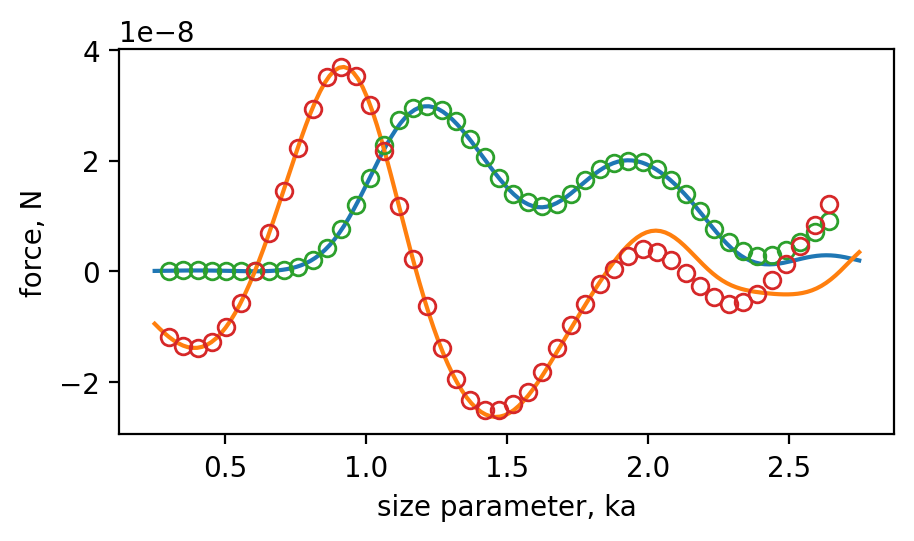

In [10]:
comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\pwh_ka_32_comsol.csv", delimiter=",", skiprows=5, dtype=float)

C_MED = 1480
ka_comsol = 2 * np.pi * comsol_tab[1:, 0] / C_MED * R_PAR
fx_comsol = comsol_tab[1:, 1]
fz_comsol = comsol_tab[1:, 2]

fig, ax = plt.subplots(1, figsize=(5, 2.5))
fig.subplots_adjust(wspace=0.1)

ax.plot(ka_vals, forces_x, label='fx')
ax.plot(ka_vals, forces_z, label='fz')
ax.plot(ka_comsol, fx_comsol, linestyle='', marker='o', mfc='none')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='o', mfc='none')

ax.set(xlabel="size parameter, ka", ylabel="force, N")
plt.show()

In [53]:
def one_water_sphere_above_hard_substrate_height(nmax, k_dheight, ka):
    # Water
    RHO_MED = 997
    C_MED = 1480

    # Particle
    C_PAR = 1020
    RHO_PAR = 1045
    R_PAR = 100e-6

    # Field
    K = ka / R_PAR
    FREQ = K * C_MED / 2 / np.pi
    P0 = 50e3
    DIR = np.array([0.58, 0., -0.81])
    
    height = k_dheight / K
    pos1 = np.array([0, 0, R_PAR + height])  # [m]

    incident_field = PlaneWave(k=K, amplitude=P0, direction=DIR)

    fluid = MediumSystem([
            FluidMedium(density=RHO_MED, sound_speed_longitudinal=C_MED), 
            RigidBoundary()
    ])

    particles = [
        SphericalParticle(
            position=pos1, 
            radius=R_PAR, 
            density=RHO_PAR, 
            sound_speed_longitudinal=C_PAR,
            multipole_order=nmax
        )
    ]

    sim = Simulation(
        particles=np.array(particles), 
        medium=fluid, 
        initial_field=incident_field, 
        frequency=FREQ, 
        order=nmax
    )
    sim.run()

    frcs = all_forces(sim)
    return frcs

In [60]:
nmax_vals = np.arange(1, 15)
kdh_vals = np.array([0, 1e-2, 1e-1, 1, 10])
# forces = np.zeros((len(kdh_vals), len(nmax_vals), 3))

# for i, kdh in enumerate(tqdm(kdh_vals)):
#     for j, n in enumerate(nmax_vals):
#         f = one_water_sphere_above_hard_substrate_height(n, kdh, ka=1)
#         forces[i, j] = f[0]

# np.save('.\\testing_examples\\tables\\rigid\\multipoles_height', forces)


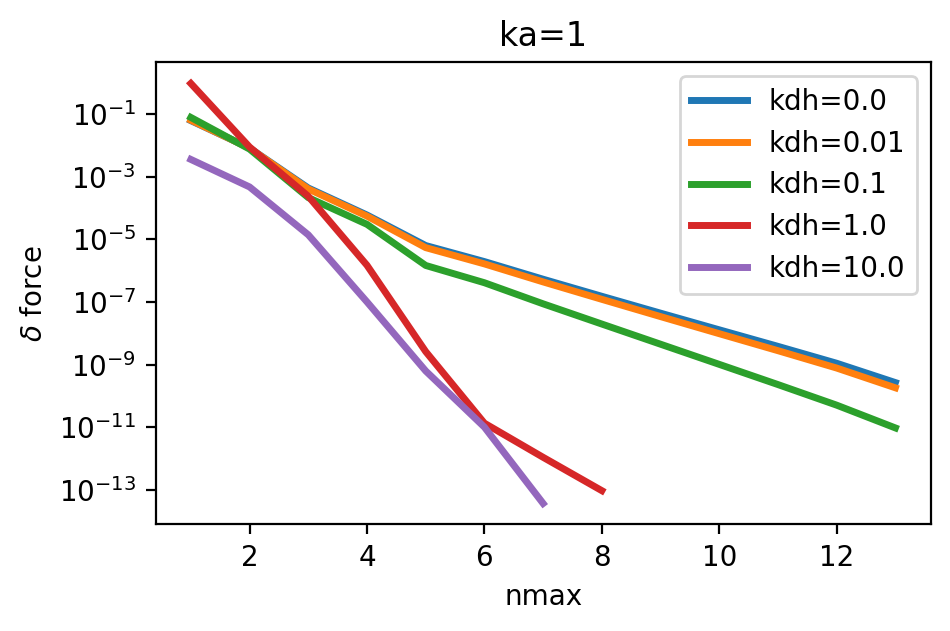

In [61]:
forces = np.load('.\\testing_examples\\tables\\rigid\\multipoles_height.npy')

fig, ax = plt.subplots(1, figsize=(5, 3))
fig.subplots_adjust(wspace=0.1)
for i, kdh in enumerate(kdh_vals):
    err = (forces[i,:-1,0] - forces[i,-1,0]) / forces[i,-1,0]
    cut = abs(err) > 5e-15
    ax.semilogy(nmax_vals[:-1][cut], abs(err)[cut], label=f'kdh={kdh}', lw=2.5)

ax.set(xlabel="nmax", ylabel="$\\delta$ force", title='ka=1')
ax.legend(loc='upper right')
plt.show()

In [62]:
nmax_vals = np.arange(1, 15)
kdh_vals = np.array([0, 1e-3, 1e-2, 1e-1, 1])
# forces = np.zeros((len(kdh_vals), len(nmax_vals), 3))

# for i, kdh in enumerate(tqdm(kdh_vals)):
#     for j, n in enumerate(nmax_vals):
#         f = one_water_sphere_above_hard_substrate_height(n, kdh, ka=0.01)
#         forces[i, j] = f[0]

# np.save('.\\testing_examples\\tables\\rigid\\multipoles_height_ka001', forces)

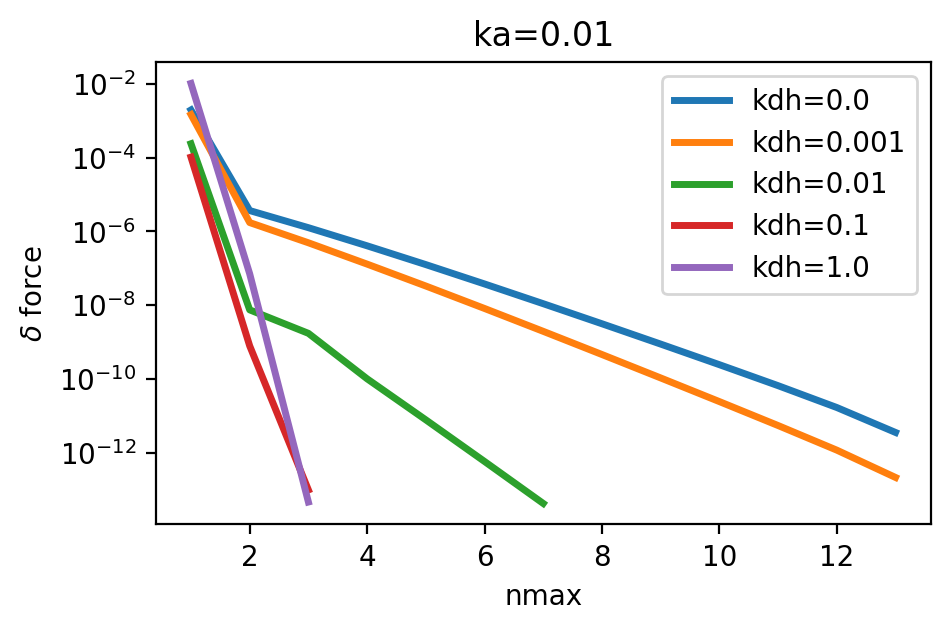

In [63]:
forces = np.load('.\\testing_examples\\tables\\rigid\\multipoles_height_ka001.npy')

fig, ax = plt.subplots(1, figsize=(5, 3))
fig.subplots_adjust(wspace=0.1)
for i, kdh in enumerate(kdh_vals):
    err = (forces[i,:-1,0] - forces[i,-1,0]) / forces[i,-1,0]
    cut = abs(err) > 5e-15
    ax.semilogy(nmax_vals[:-1][cut], abs(err)[cut], label=f'kdh={kdh}', lw=2.5)

ax.set(xlabel="nmax", ylabel="$\\delta$ force", title='ka=0.01')
ax.legend(loc='upper right')
plt.show()